# 01 — Poisson equation (PINN-PC and SPINN-NC)

This notebook merges and cleans the legacy `poisson_equation` and `poisson_neural_chaos` workflows into one reproducible chapter notebook.

In [1]:
import os
import time
from pathlib import Path

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from tqdm import tqdm

import deepxde as dde
import jax
import jax.numpy as jnp

from phd.plot import get_current_config as plt_cfg, book_config, KUL_CYCLE

book_config.set_as_current()
page_width = plt_cfg().page_width
mpl.rcParams["axes.prop_cycle"] = mpl.cycler(color=KUL_CYCLE)

save_fig = True
if save_fig:
    mpl.rcParams["pgf.texsystem"] = "pdflatex"

def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for parent in [current, *current.parents]:
        if (parent / "pyproject.toml").exists():
            return parent
    raise FileNotFoundError("Could not find project root (missing pyproject.toml).")

PROJECT_ROOT = find_project_root(Path.cwd())
CHAPTER_DIR = PROJECT_ROOT / "chapters" / "V_UncertaintyPropagation" / "01_poisson_equation"
IMAGE_DIR = CHAPTER_DIR / "images"
PGF_DIR = IMAGE_DIR / "pgf"
PNG_DIR = IMAGE_DIR / "png"
DATA_DIR = CHAPTER_DIR / "data"

for d in [PGF_DIR, PNG_DIR, DATA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def save_figure(fig, name: str, dpi: int = 300):
    if not save_fig:
        return
    fig.savefig(PGF_DIR / f"{name}.pgf", bbox_inches="tight")
    fig.savefig(PNG_DIR / f"{name}.png", bbox_inches="tight", dpi=dpi)

print(f"Project root: {PROJECT_ROOT}")
print(f"Chapter dir: {CHAPTER_DIR}")

Using backend: jax
Other supported backends: tensorflow.compat.v1, tensorflow, pytorch, paddle.
paddle supports more examples now and is recommended.
Enable just-in-time compilation with XLA.



Project root: /home/r2d2/code/PhD
Chapter dir: /home/r2d2/code/PhD/chapters/V_UncertaintyPropagation/01_poisson_equation


## Problem setup

We solve

$-u''(x, \boldsymbol{\xi}) = f(x, \boldsymbol{\xi}), \quad x\in[-1,1], \quad u(-1)=u(1)=0$

with
$f(x, \boldsymbol{\xi}) \sim \mathcal{GP}(f_0(x), k(x,x'))$,
$f_0(x)=10\sin(\pi x)$,
$k(x,x')=\sigma^2 \exp(-((x-x')^2/l^2))$,
$\sigma=1$, $l=0.5$.

In [2]:
SEED = 42
np.random.seed(SEED)

sigma = 1.0
corr_length = 0.5

def f0(x):
    return 10.0 * np.sin(np.pi * x)

def kernel(x, x_prime, sigma=sigma, l=corr_length):
    return sigma**2 * np.exp(-((x - x_prime) ** 2) / l**2)

def sample_gp(x_grid, n_samples=1):
    mu = f0(x_grid)
    K = np.array([[kernel(xi, xj) for xj in x_grid] for xi in x_grid])
    return np.random.multivariate_normal(mu, K, n_samples)

def solve_poisson_fd(f_values, dx, u_left=0.0, u_right=0.0):
    f_values = np.asarray(f_values).copy()
    n = len(f_values)
    diagonals = [-2.0 * np.ones(n), np.ones(n - 1), np.ones(n - 1)]
    A = diags(diagonals, [0, 1, -1], format="csr") / dx**2
    f_values[0] += u_left / dx**2
    f_values[-1] += u_right / dx**2
    return spsolve(A, -f_values)

def kl_expansion(x_grid, truncation_order):
    K = np.array([[kernel(xi, xj) for xj in x_grid] for xi in x_grid])
    eigvals, eigvecs = eigh(K)
    idx = eigvals.argsort()[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    for i in range(truncation_order):
        if eigvecs[0, i] < 0:
            eigvecs[:, i] *= -1
    return eigvals[:truncation_order], eigvecs[:, :truncation_order]

def forcing_from_xi(xi, x_grid, eigvals, eigvecs):
    return f0(x_grid) + (np.sqrt(eigvals) * xi) @ eigvecs.T

def pce_projection_modes(u_samples, xi_samples):
    n = xi_samples.shape[0]
    return (xi_samples.T @ u_samples) / n

## KL discretization of the forcing field

<>:14: SyntaxWarning: invalid escape sequence '\%'
<>:14: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_132992/3356164098.py:14: SyntaxWarning: invalid escape sequence '\%'
  ax1.set_ylabel("Explained variance (\%)")


99.0% variance retained with M = 6


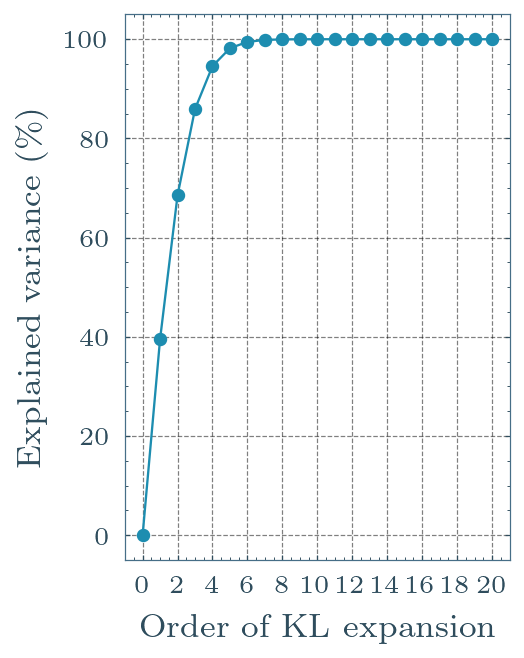

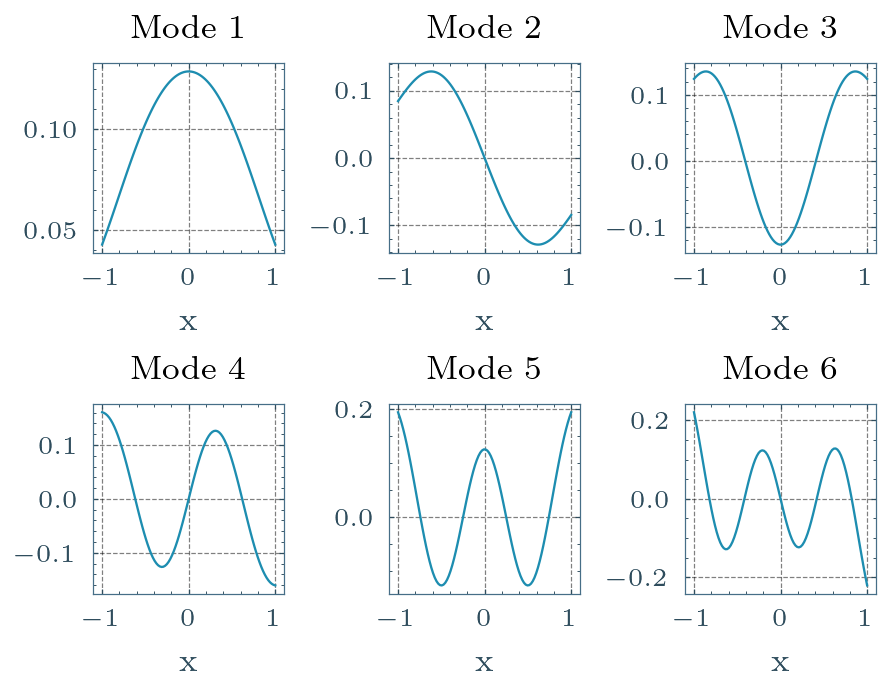

In [3]:
n_kl_points = 100
x_kl = np.linspace(-1.0, 1.0, n_kl_points)
eigvals_kl, eigvecs_kl = kl_expansion(x_kl, truncation_order=20)
explained_var = np.cumsum(eigvals_kl) / np.sum(eigvals_kl)

threshold = 0.99
truncation_order = int(np.argmax(explained_var >= threshold) + 1)
print(f"{100*threshold:.1f}% variance retained with M = {truncation_order}")

fig1, ax1 = plt.subplots(figsize=(0.35 * page_width, 0.5 * page_width), dpi=300)
n_orders = 20
ax1.plot(np.arange(0, n_orders + 1), [0.0] + list(100 * explained_var[:n_orders]), marker="o")
ax1.set_xlabel("Order of KL expansion")
ax1.set_ylabel("Explained variance (\%)")
ax1.set_xticks(np.arange(0, n_orders + 1, 2))
save_figure(fig1, "KL_expansion")
plt.show()

fig2, axs = plt.subplots(2, 3, figsize=(0.65 * page_width, 0.5 * page_width), dpi=300)
for i, ax in enumerate(axs.flat):
    ax.plot(x_kl, eigvecs_kl[:, i])
    ax.set_title(f"Mode {i+1}")
    ax.set_xlabel("x")
    ax.set_box_aspect(1)          # square plotting area

save_figure(fig2, "kl_eigenfunctions")
plt.tight_layout()
plt.show()

## Monte Carlo reference (using precomputed $10^6$-sample PCE modes)

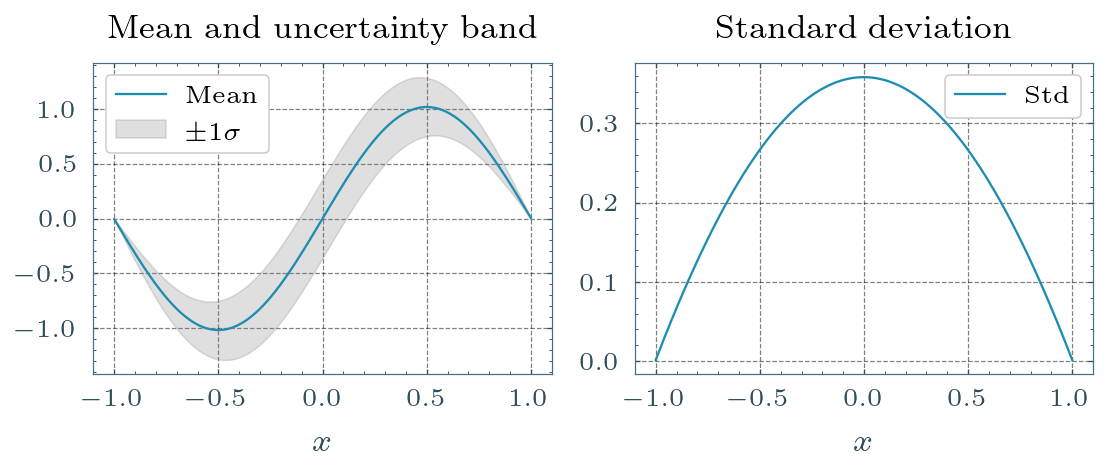

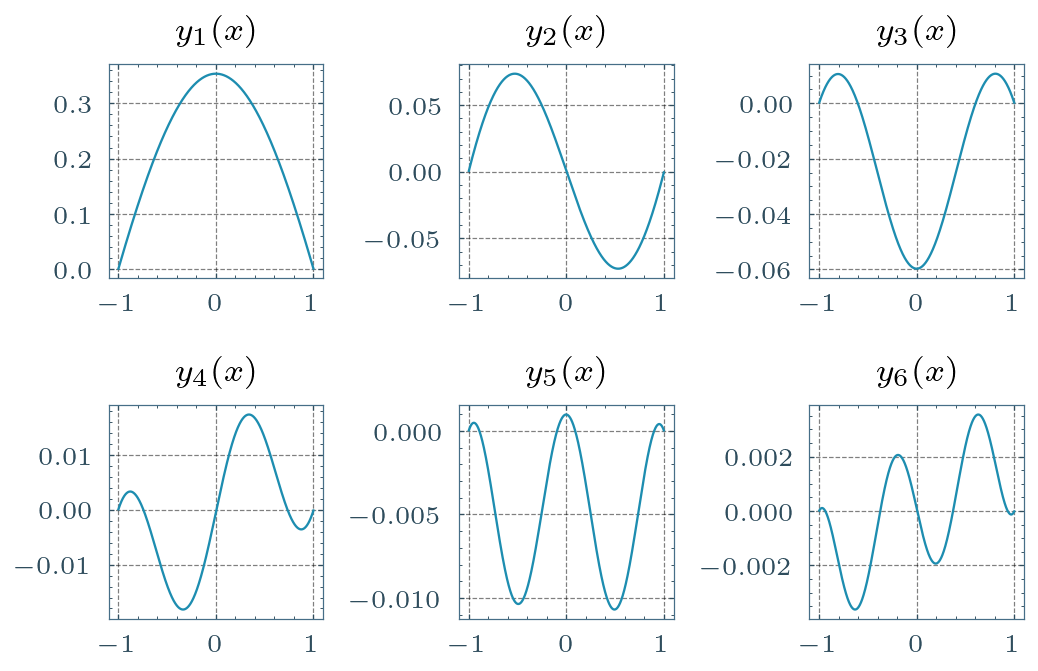

In [4]:
reference_modes_path = DATA_DIR / "MonteCarlo_PCE_modes_1e6.0.npy"
if not reference_modes_path.exists():
    raise FileNotFoundError(f"Missing reference file: {reference_modes_path}")

reference_modes = np.load(reference_modes_path)
x_ref = np.linspace(-1.0, 1.0, reference_modes.shape[1])
dx_ref = x_ref[1] - x_ref[0]
u_mean_ref = solve_poisson_fd(f0(x_ref), dx_ref)
u_std_ref = np.sqrt(np.sum(reference_modes**2, axis=0))

fig3, axs = plt.subplots(1, 2, figsize=(0.8 * page_width, 0.35 * page_width), dpi=300)
axs[0].plot(x_ref, u_mean_ref, label="Mean")
axs[0].fill_between(x_ref, u_mean_ref - u_std_ref, u_mean_ref + u_std_ref, alpha=0.25, label=r"$\pm 1\sigma$", color="gray", linewidth=plt_cfg().scale)
axs[0].set_xlabel(r"$x$")
axs[0].set_title("Mean and uncertainty band")
axs[0].legend().get_frame().set_linewidth(plt_cfg().scale)

axs[1].plot(x_ref, u_std_ref, label="Std")
axs[1].set_xlabel(r"$x$")
axs[1].set_title("Standard deviation")
axs[1].legend().get_frame().set_linewidth(plt_cfg().scale)

save_figure(fig3, "MC_poisson")
plt.tight_layout()
plt.show()

fig4, axs = plt.subplots(2, 3, figsize=(0.75* page_width, 0.5 * page_width), dpi=300)
for i, ax in enumerate(axs.flat):
    ax.plot(x_ref, reference_modes[i])
    ax.set_title(f"$y_{{{i+1}}}(x)$")
    # ax.set_xlabel("x")
    ax.set_box_aspect(1)          # square plotting area
save_figure(fig4, "PCE_eigenfunctions")
plt.tight_layout()
plt.show()

## PINN-PC training and results

In [7]:
from importlib import reload
reload(dde)

# Hyperparameters (matching the chapter text)
M = 6
n_sensors = 13
n_x_points = 100
n_xi_samples = 100_000
n_xi_batch = 1_000
bc_type = "hard"

x_train = np.linspace(-1.0, 1.0, n_x_points)
eigvals_train, eigvecs_train = kl_expansion(x_train, truncation_order=M)

xi_train = np.random.randn(n_xi_samples, M)
f_samples = np.array([forcing_from_xi(xi, x_train, eigvals_train, eigvecs_train) for xi in xi_train])

sensor_idx = np.linspace(0, n_x_points - 1, n_sensors, dtype=int)
x_sensor = x_train[sensor_idx]
f_sensor = f_samples[:, sensor_idx]

dtype = dde.backend.data_type_dict["float32"]
xi_train_t = dde.backend.as_tensor(xi_train, dtype=dtype)
f_sensor_t = dde.backend.as_tensor(f_sensor, dtype=dtype)

def hessian(y, x, comp=0, i=0, j=0):
    h = dde.grad.hessian(y, x, comp, i, j)
    return h[0] if dde.backend.backend_name == "jax" else h

def pde_pinn_pc(x, net_output):
    indices = np.random.permutation(xi_train_t.shape[0])[:n_xi_batch]
    xi_batch = xi_train_t[indices]
    f_batch = f_sensor_t[indices]

    d2u_mean = hessian(net_output, x).flatten()
    d2u_coeffs = []
    for i_mode in range(1, M + 1):
        d2u_coeffs.append(hessian(net_output, x, i_mode))
    d2u_coeffs = dde.backend.stack(d2u_coeffs, 1).squeeze()

    d2u_dx2 = d2u_mean + xi_batch @ d2u_coeffs.T
    residual = d2u_dx2 + f_batch

    losses = [residual]
    if bc_type == "soft":
        if dde.backend.backend_name == "jax":
            net_output = net_output[0]
        u_pred = net_output[:, :1].flatten() + xi_batch @ net_output[:, 1:].T
        losses += [u_pred[:, 0], u_pred[:, -1]]
    return losses

def hard_bc_pinn_pc(x, u):
    return u * (1 + x) * (1 - x)

geom = dde.geometry.Interval(-1.0, 1.0)
data = dde.data.PDE(geom, pde_pinn_pc, bcs=[], num_domain=0, anchors=x_sensor.reshape(-1, 1))

layer_size = [1] + [[4,36]]*3 + [[1, M]]
regularization = ["l2", 1e-5]
net = dde.nn.PFNN(layer_size, "tanh", "Glorot uniform", regularization=regularization)
if bc_type == "hard":
    net.apply_output_transform(hard_bc_pinn_pc)

model_pc = dde.Model(data, net)
model_pc.compile("adam", lr=1e-3)
losshistory_pc, train_state_pc = model_pc.train(iterations=40_000, display_every=1000)

Training model...

Step      Train loss              Test loss               Test metric
30000     [1.35e-04, 9.58e-04]    [1.35e-04, 9.58e-04]    []  
31000     [4.65e-04, 9.44e-04]    [4.43e-04, 9.44e-04]    []  
32000     [1.19e-04, 9.31e-04]    [1.22e-04, 9.31e-04]    []  
33000     [3.17e-04, 9.18e-04]    [3.10e-04, 9.18e-04]    []  
34000     [1.62e-04, 9.05e-04]    [1.64e-04, 9.05e-04]    []  
35000     [1.35e-04, 8.93e-04]    [1.31e-04, 8.93e-04]    []  
36000     [3.47e-04, 8.82e-04]    [3.31e-04, 8.82e-04]    []  
37000     [7.47e-05, 8.71e-04]    [7.44e-05, 8.71e-04]    []  
38000     [1.51e-04, 8.61e-04]    [1.50e-04, 8.61e-04]    []  
39000     [1.36e-04, 8.50e-04]    [1.38e-04, 8.50e-04]    []  
40000     [3.44e-04, 8.40e-04]    [3.48e-04, 8.40e-04]    []  
41000     [1.03e-04, 8.31e-04]    [1.02e-04, 8.31e-04]    []  
42000     [2.22e-04, 8.21e-04]    [2.22e-04, 8.21e-04]    []  
43000     [1.16e-04, 8.12e-04]    [1.25e-04, 8.12e-04]    []  
44000     [1.89e-04, 8.02e-04

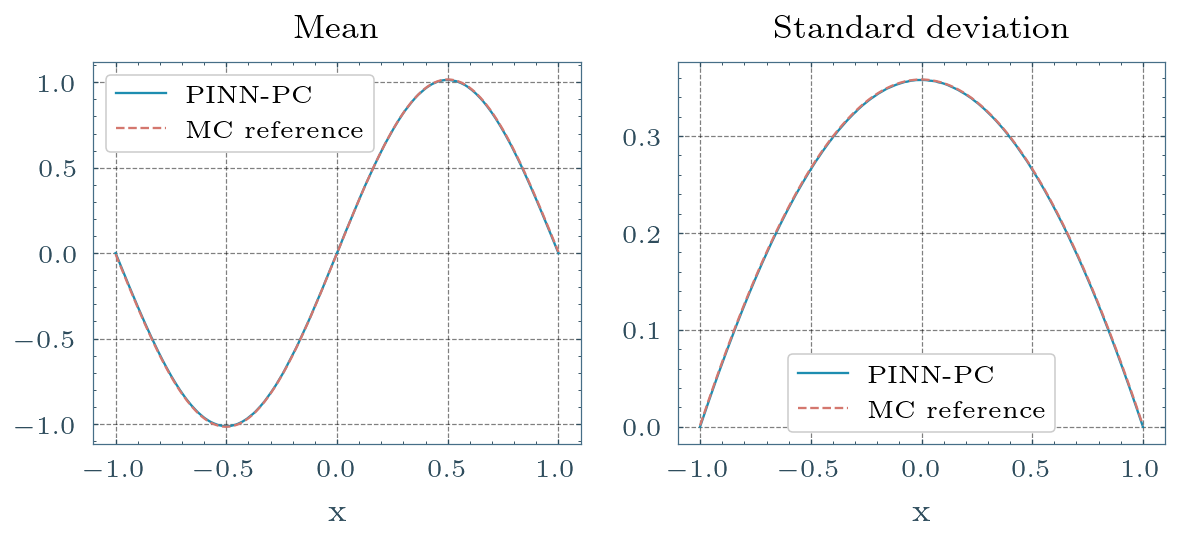

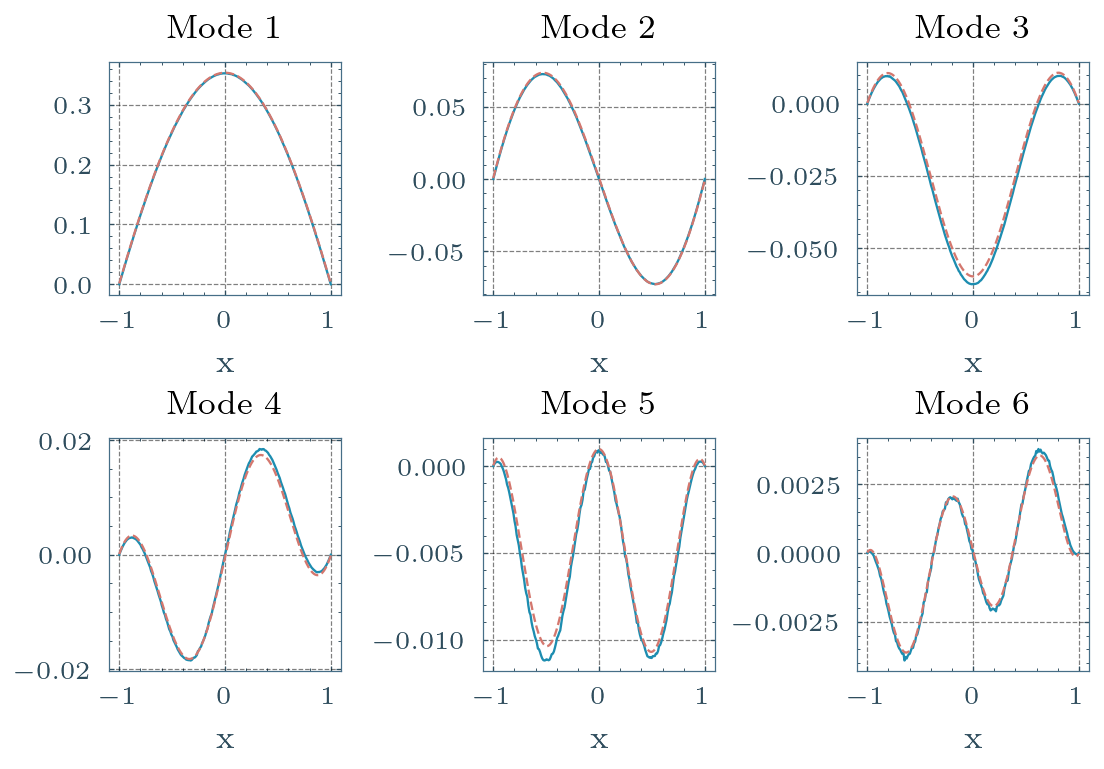

In [8]:
# PINN-PC: mean/std and coefficient comparison
x_plot = np.linspace(-1.0, 1.0, 200).reshape(-1, 1)
pred_mean = model_pc.predict(x_plot)[:, :1].flatten()
pred_coeffs = model_pc.predict(x_plot)[:, 1:]
pred_std = np.sqrt(np.sum(pred_coeffs**2, axis=1))

x_ref_interp = np.linspace(-1.0, 1.0, len(u_mean_ref))
u_mean_interp = np.interp(x_plot.flatten(), x_ref_interp, u_mean_ref)
u_std_interp = np.interp(x_plot.flatten(), x_ref_interp, u_std_ref)

fig5, axs = plt.subplots(1, 2, figsize=(0.85 * page_width, 0.4 * page_width), dpi=300)
axs[0].plot(x_plot, pred_mean, label="PINN-PC")
axs[0].plot(x_plot, u_mean_interp, "--", label="MC reference")
axs[0].set_title("Mean")
axs[0].set_xlabel("x")
axs[0].legend().get_frame().set_linewidth(plt_cfg().scale)

axs[1].plot(x_plot, pred_std, label="PINN-PC")
axs[1].plot(x_plot, u_std_interp, "--", label="MC reference")
axs[1].set_title("Standard deviation")
axs[1].set_xlabel("x")
axs[1].legend().get_frame().set_linewidth(plt_cfg().scale)

save_figure(fig5, "PINN-PC_poisson")
plt.tight_layout()
plt.show()

fig6, axs = plt.subplots(2, 3, figsize=(0.8 * page_width, 0.55 * page_width), dpi=300)
for i, ax in enumerate(axs.flat):
    ax.plot(x_plot, pred_coeffs[:, i], label="PINN-PC")
    ax.plot(x_ref, reference_modes[i], "--", label="MC")
    ax.set_title(f"Mode {i+1}")
    ax.set_xlabel("x")
    ax.set_box_aspect(1)          # square plotting area
save_figure(fig6, "PINN-PC_eigenfunctions")
plt.tight_layout()
plt.show()

## SPINN-NC training and results

In [9]:
# SPINN-NC setup (cleaned version of legacy notebook)
rank_nc = 3
n_sensors_nc = 13
n_x_points_nc = 100
n_xi_samples_nc = 10_000
n_xi_batch_nc = 1_000
bc_type_nc = "hard"

x_train_nc = np.linspace(-1.0, 1.0, n_x_points_nc)
eigvals_nc, eigvecs_nc = kl_expansion(x_train_nc, truncation_order=M)
xi_train_nc = np.random.randn(n_xi_samples_nc, M)
f_samples_nc = np.array([forcing_from_xi(xi, x_train_nc, eigvals_nc, eigvecs_nc) for xi in xi_train_nc])

sensor_idx_nc = np.linspace(0, n_x_points_nc - 1, n_sensors_nc, dtype=int)
x_sensor_nc = x_train_nc[sensor_idx_nc].reshape(-1, 1)
f_sensor_nc = f_samples_nc[:, sensor_idx_nc].T

dtype = dde.backend.data_type_dict["float32"]
xi_train_nc_t = dde.backend.as_tensor(xi_train_nc, dtype=dtype)
f_sensor_nc_t = dde.backend.as_tensor(f_sensor_nc, dtype=dtype)

def u_from_mixnn(x, net_fun, xi):
    output = net_fun([x, xi])
    coeff = output[0]
    basis = output[1]
    if basis.ndim == 1:
        basis = basis.reshape(1, -1)
    xi_aug = jnp.hstack([jnp.ones((basis.shape[0], 1)), basis]).T
    return jnp.dot(coeff, xi_aug)

def orthogonality_loss(basis_values):
    n_batch = basis_values.shape[0]
    gram = (basis_values.T @ basis_values) / n_batch
    identity = jnp.eye(gram.shape[0])
    return jnp.linalg.norm(gram - identity)

def pde_spinn_nc(x, f):
    indices = np.random.permutation(xi_train_nc_t.shape[0])[:n_xi_batch_nc]
    xi_batch = x[1][indices]
    f_batch = f_sensor_nc_t[:, indices]

    f_x = lambda z: u_from_mixnn(z, f[1], xi_batch)
    hess_f = jax.jacfwd(jax.jacfwd(f_x, argnums=0), argnums=0)
    d2u_dx2 = jax.vmap(hess_f)(x[0]).squeeze()

    pde_residual = d2u_dx2 + f_batch
    ortho_residual = orthogonality_loss(f[0][1])

    losses = [pde_residual, ortho_residual]
    if bc_type_nc == "soft":
        if dde.backend.backend_name == "jax":
            f = f[0]
        u_pred = f[:, :1].flatten() + xi_batch @ f[:, 1:].T
        losses += [u_pred[:, 0], u_pred[:, -1]]
    return losses

def hard_bc_spinn_nc(x, output):
    return (output[0] * (1.0 + x[0]) * (1.0 - x[0]), output[1])

geom_nc = dde.geometry.ListPointCloud([x_sensor_nc, xi_train_nc_t])
data_nc = dde.data.PDE(geom_nc, pde_spinn_nc, bcs=[], num_domain=10, is_SPINN=True, num_test=10)

x_layer_size = [1] + [[4, 32]] * 3 + [[1, rank_nc + 1]]
xi_layer_size = [M, 16, 16, rank_nc]
x_net = dde.nn.PFNN(x_layer_size, "tanh", "Glorot uniform", ["l2", 1e-5])
xi_net = dde.nn.FNN(xi_layer_size, "tanh", "Glorot uniform", ["l2", 1e-5], True)
net_nc = dde.nn.MixNN(networks=[x_net, xi_net])
if bc_type_nc == "hard":
    net_nc.apply_output_transform(hard_bc_spinn_nc)

model_nc = dde.Model(data_nc, net_nc)
model_nc.compile("adam", lr=1e-3, loss_weights=[1.0, 1.0])
losshistory_nc, train_state_nc = model_nc.train(iterations=5_000, display_every=500)

Compiling model...
'compile' took 2.993733 s

Training model...



TypeError: concatenate requires ndarray or scalar arguments, got <class 'tuple'> at position 0.

In [ ]:
# Check orthogonality of learned stochastic basis
n_xi_check = 100_000
x_check = np.linspace(-1.0, 1.0, n_x_points_nc).reshape(-1, 1)
xi_check = np.random.randn(n_xi_check, M)
basis_values = model_nc.net.apply(model_nc.net.params, [x_check, xi_check])[1]
gram = (basis_values.T @ basis_values) / basis_values.shape[0]
np.set_printoptions(precision=3, suppress=True)
print("Empirical covariance (basis Gram matrix):")
print(np.array(gram))

In [ ]:
# SPINN-NC mean/std vs reference
x_plot_nc = np.linspace(-1.0, 1.0, 200).reshape(-1, 1)
xi_plot_nc = np.random.randn(10_000, M)
y_pred_nc = lambda z: model_nc.net.apply(model_nc.net.params, z)
u_pred_nc = u_from_mixnn(x_plot_nc, y_pred_nc, xi_plot_nc)

mean_nc = np.mean(np.array(u_pred_nc), axis=1)
std_nc = np.std(np.array(u_pred_nc), axis=1)

u_mean_interp_nc = np.interp(x_plot_nc.flatten(), x_ref, u_mean_ref)
u_std_interp_nc = np.interp(x_plot_nc.flatten(), x_ref, u_std_ref)

fig7, axs = plt.subplots(1, 2, figsize=(0.85 * page_width, 0.35 * page_width))
axs[0].plot(x_plot_nc, mean_nc, label="SPINN-NC")
axs[0].plot(x_plot_nc, u_mean_interp_nc, "--", label="MC reference")
axs[0].set_title("Mean")
axs[0].set_xlabel("x")
axs[0].legend()

axs[1].plot(x_plot_nc, std_nc, label="SPINN-NC")
axs[1].plot(x_plot_nc, u_std_interp_nc, "--", label="MC reference")
axs[1].set_title("Standard deviation")
axs[1].set_xlabel("x")
axs[1].legend()

save_figure(fig7, "PINN_NC_mean_std")
plt.tight_layout()
plt.show()

In [ ]:
# SPINN-NC train/test MSE distributions
x_eval = np.linspace(-1.0, 1.0, 300)
dx_eval = x_eval[1] - x_eval[0]
eigvals_eval, eigvecs_eval = kl_expansion(x_eval, truncation_order=M)

n_eval = 2000
xi_eval_train = np.array(xi_train_nc[:n_eval])
xi_eval_test = np.random.randn(n_eval, M)

u_pred_train = np.array(u_from_mixnn(x_eval.reshape(-1, 1), y_pred_nc, xi_eval_train))
u_pred_test = np.array(u_from_mixnn(x_eval.reshape(-1, 1), y_pred_nc, xi_eval_test))

f_train = [forcing_from_xi(xi, x_eval, eigvals_eval, eigvecs_eval) for xi in tqdm(xi_eval_train)]
f_test = [forcing_from_xi(xi, x_eval, eigvals_eval, eigvecs_eval) for xi in tqdm(xi_eval_test)]
u_ref_train = np.array([solve_poisson_fd(fv, dx_eval) for fv in tqdm(f_train)]).T
u_ref_test = np.array([solve_poisson_fd(fv, dx_eval) for fv in tqdm(f_test)]).T

mse_train = np.mean((u_pred_train - u_ref_train) ** 2, axis=1)
mse_test = np.mean((u_pred_test - u_ref_test) ** 2, axis=1)

log_mse_train = np.log10(mse_train + 1e-14)
log_mse_test = np.log10(mse_test + 1e-14)

fig8, ax = plt.subplots(figsize=(0.45 * page_width, 0.45 * page_width))
ax.hist(log_mse_train, bins=30, density=True, alpha=0.35, label="Train")
ax.hist(log_mse_test, bins=30, density=True, alpha=0.35, label="Test")
ax.set_xlabel("log10(MSE)")
ax.set_ylabel("Density")
ax.legend()

save_figure(fig8, "PINN-NC_MSE_density")
plt.tight_layout()
plt.show()

## Coherence checklist with LaTeX section

- Domain and forcing now match the original reference notebook: $x\in[-1,1]$, $f_0(x)=10\sin(\pi x)$, $\sigma=1$, $l=0.5$.
- KL truncation target is 99% and gives $M=6$.
- Generated figures (pgf + png):
  - `KL_expansion`, `kl_eigenfunctions`, `MC_poisson`, `PCE_eigenfunctions`
  - `PINN-PC_poisson`, `PINN-PC_eigenfunctions`
  - `PINN_NC_mean_std`, `PINN-NC_MSE_density`
- All figures are saved in `images/pgf` and `images/png`.